**Задача 1** - реализация series test

In [3]:
from scipy import stats
import numpy as np
import math
import matplotlib.pyplot as plt

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1
samples = np.array([rng() for _ in range(1000)])

def series_test(samples):
    N = len(samples)
    
    for d in range(1, 10):
        # Trim to multiple of d
        Nd = (N // d)
        samples_trim = samples[:(Nd * d)]
        points = samples_trim.reshape(-1, d)
        num_points = len(points) # соединяем в d - мерные точки
        k = int((num_points // 6)**(1/d)) # делаем такое k, что в каждой E_i > 5 для всех i
        num_bins = k ** d
        if ((num_points / num_bins) < 6) or (k < 2):
            print("too few samples to work with")
            break
        bins = [np.linspace(0, 1, k + 1) for _ in range(d)]
        f_obs, edges = np.histogramdd(points, bins=bins)
        f_obs = f_obs.flatten()
        f_exp = np.full(num_bins, num_points / num_bins)
        res = stats.chisquare(f_obs, f_exp)
        p = res.pvalue
        if p > 0.05:
            print(f"d = {d}: passed, pvalue = {p}")
        else:
            print(f"d = {d}: failed, pvalue = {p}")

series_test(samples)

d = 1: passed, pvalue = 0.6589920080022522
d = 2: passed, pvalue = 0.21516098226090657
d = 3: passed, pvalue = 0.07268438663014308
d = 4: passed, pvalue = 0.5110200984502635
d = 5: passed, pvalue = 0.51316765715053
too few samples to work with


**Задача 2**: permutation test

In [4]:
import numpy as np

def lehmer_code(perm):
    n = len(perm)
    rank = 0
    used = [False] * n
    for i in range(n):
        smaller = 0
        for j in range(perm[i]):
            if not used[j]:
                smaller += 1
        rank += smaller * math.factorial(n - i - 1)
        used[perm[i]] = True
    return rank

def permutation_test(samples, max_d=9):
    N = len(samples)
    samples = np.array(samples)
    
    for d in range(1, max_d + 1):
        if N < d * 10:
            print(f"Skipping d={d}: not enough data")
            continue
            
        n_full = N // d
        trimmed = samples[:n_full * d].reshape(-1, d)
        n_blocks = len(trimmed)
        
        ranking_perms = [np.argsort(block) for block in trimmed]
        ranks = np.array([lehmer_code(perm) for perm in ranking_perms])
        
        total_perms = math.factorial(d)
        if n_blocks < total_perms * 5:
            print(f"d={d}: only {n_blocks} blocks, {total_perms} possible perms → low power")
        
        obs_freq = np.bincount(ranks, minlength=total_perms)
        exp_freq = np.full(total_perms, n_blocks / total_perms)
        
        if np.all(exp_freq >= 5):
            chi2, p = stats.chisquare(obs_freq, exp_freq)
            if p < 0.05:
                print(f"d = {d}: failed (p={p:.4f})")
            else:
                print(f"d = {d}: passed (p={p:.3f})")
        else:
            print(f"d >= {d}: too few observations per pattern, test not reliable")
            break

permutation_test(samples)

d = 1: passed (p=nan)
d = 2: passed (p=0.858)
d = 3: passed (p=0.434)
d = 4: passed (p=0.482)
d=5: only 200 blocks, 120 possible perms → low power
d >= 5: too few observations per pattern, test not reliable


**Задача 3**: привести примеры, когда rng_bad плох, а rng  - хорош


In [5]:
def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

bad_samples = np.array([rng_bad() for _ in range(0, 1000000)])
print("для плохого:")
print("permutstion_test:")
permutation_test(bad_samples)
print("series test:")
series_test(bad_samples)
print("для хорошего:")
print("permutstion_test:")
samples = np.array([rng() for _ in range(1000000)])
permutation_test(samples)
print("series test:")
series_test(samples)

для плохого:
permutstion_test:
d = 1: passed (p=nan)
d = 2: passed (p=0.445)
d = 3: passed (p=0.337)
d = 4: passed (p=0.522)
d = 5: passed (p=0.235)
d = 6: failed (p=0.0047)
d = 7: passed (p=0.066)
d=8: only 125000 blocks, 40320 possible perms → low power
d >= 8: too few observations per pattern, test not reliable
series test:
d = 1: passed, pvalue = 0.33216188195954793
d = 2: passed, pvalue = 0.8873951392090982
d = 3: failed, pvalue = 0.0
d = 4: failed, pvalue = 0.0
d = 5: failed, pvalue = 1.1910448669751489e-179
d = 6: failed, pvalue = 9.100114885600047e-06
d = 7: failed, pvalue = 0.0022897882466361144
d = 8: passed, pvalue = 0.29381828109063685
d = 9: passed, pvalue = 0.1953456234459532
для хорошего:
permutstion_test:
d = 1: passed (p=nan)
d = 2: passed (p=0.939)
d = 3: passed (p=0.415)
d = 4: passed (p=0.798)
d = 5: passed (p=0.310)
d = 6: passed (p=0.943)
d = 7: passed (p=0.944)
d=8: only 125000 blocks, 40320 possible perms → low power
d >= 8: too few observations per pattern, tes

Ответ: series_test при размерностях d>=3

**Задача 4**: Смоделировать выборку объема 1000 из дискретного распределения на множестве цифр 0, 1, 2, ..., 9 с весами 0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2. По выборке построить гистограмму. Оптимизируйте алгоритм, упорядочив веса.

In [6]:
def sample_discrete(values, weights, size=1):
    weight = np.array(weights, dtype=float)
    probs = weight / weight.sum()
    cumsum = np.cumsum(probs)
    
    samples = []
    for _ in range(size):
        r = np.random.rand()
        idx = np.searchsorted(cumsum, r)
        samples.append(values[idx])
    
    return np.array(samples)

N = 1000
values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
weights = [0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2]

samples = sample_discrete(values, weights, size=N)

print("Первые 10:", samples[:10])

Первые 10: [9 9 4 4 1 0 1 4 5 4]


**Задача 5**: Смоделируйте выборку размера 1000 из распределения  𝐸𝑥𝑝(𝜆)  с помощью метода Inverse transform. Постройте выборочную гистограмму и точный график плотности распределения.
Обратная функция = -ln(1 - u) / lambda

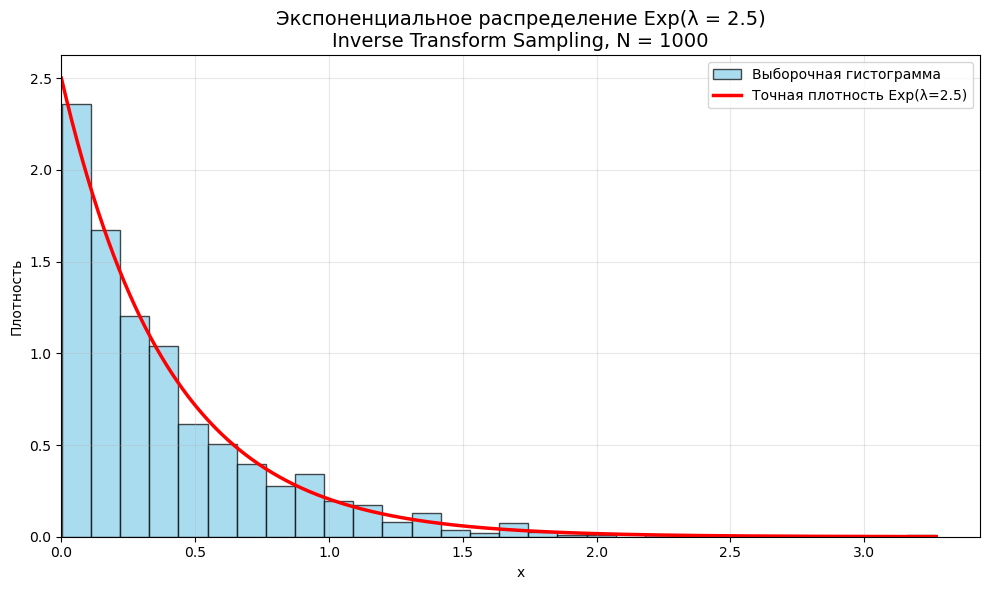

In [7]:
N = 1000
lambda_param = 2.5
np.random.seed(42)

def exp_generator(lambda_param, N):
    result = []
    for i in range(0, N):
        u = np.random.rand()
        result.append(float(-np.log(1 - u) / lambda_param))
    return result

exp = np.array(exp_generator(lambda_param, N))
plt.figure(figsize=(10, 6))

plt.hist(exp, bins=30, density=True, alpha=0.7, color='skyblue', 
         edgecolor='black', label='Выборочная гистограмма')
    
x = np.linspace(0, exp.max(), 1000)
pdf = lambda_param * np.exp(-lambda_param * x)
plt.plot(x, pdf, 'r-', lw=2.5, label=f'Точная плотность Exp(λ={lambda_param})')
plt.title(f'Экспоненциальное распределение Exp(λ = {lambda_param})\n'
          f'Inverse Transform Sampling, N = {N}', fontsize=14)
plt.xlabel('x')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, None)
plt.ylim(0, None)  
plt.tight_layout()
plt.show()

**Задача 6** Обоснуйте (устно), что метод accept-reject действительно производит выборку из нужного распределения. Смоделируйте 1000 точек из распределения с плотностью  e^x cos^2(x)  на отрезке  [−𝜋/2,𝜋/2] . По выборке постройте график выборочной гистограммы и сравните его с графиком точной функции плотности.

За известную плотность возьмем равномерное на [−𝜋/2,𝜋/2]

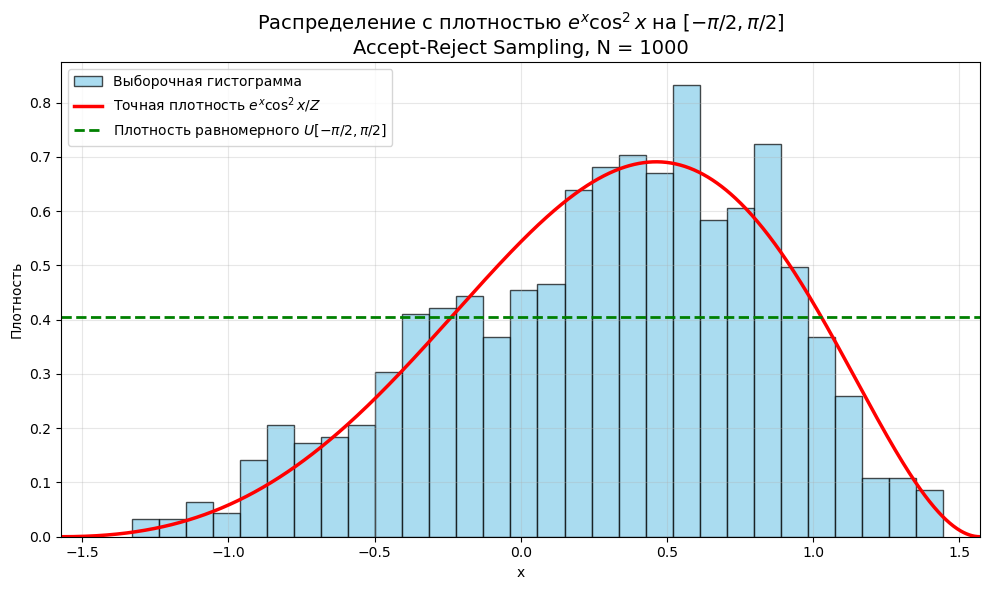

In [8]:
N = 1000
PI = np.pi
Z = (4/5) * np.sinh(np.pi/2) # нормировочная константа

def target_density(x):
    return np.exp(x) * (np.cos(x))**2

theta = np.arctan(0.5)
C = target_density(theta)

def uniform(a, b):
    x = np.random.rand()
    return a + (b - a) * x
    
def AR(N):
    samples = []
    while len(samples) < N:
        y = uniform(-PI/2, PI/2)
        u = uniform(0, 1)
        if u <= target_density(y) / C:
            samples.append(y)
    samples = np.array(samples)
    return samples

samples = np.array(AR(N))
plt.figure(figsize=(10, 6))
plt.hist(samples, bins=30, density=True, alpha=0.7, color='skyblue', 
         edgecolor='black', label='Выборочная гистограмма')
x = np.linspace(-PI/2, PI/2, 1000)
pdf = target_density(x) / Z
plt.plot(x, pdf, 'r-', lw=2.5, label='Точная плотность $e^{x} \\cos^{2} x / Z$')

# Плотность равномерного распределения g(x) = 1/π на [-π/2, π/2]
uniform_pdf = np.full_like(x, 1 / np.pi) * C
plt.plot(x, uniform_pdf, 'g--', lw=2, label='Плотность равномерного $U[-\\pi/2, \\pi/2]$')

# Оформление
plt.title(f'Распределение с плотностью $e^x \\cos^2 x$ на $[-\\pi/2, \\pi/2]$\n'
          f'Accept-Reject Sampling, N = {N}', fontsize=14)
plt.xlabel('x')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(-PI/2, PI/2)
plt.ylim(0, None)

plt.tight_layout()
plt.show()


**Задача 7**
Смоделировать и изобразить выборку из 500 точек равномерно распределенных внутри данного треугольника без использования метода отбора.

(np.float64(0.6499999999999999),
 np.float64(8.35),
 np.float64(0.75),
 np.float64(6.25))

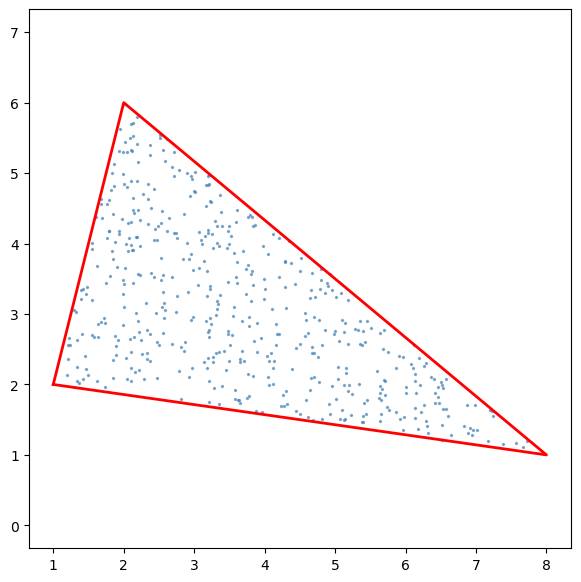

In [9]:
def triangle_uniform_generator(triangle, N):
    A, B, C = triangle
    x = []
    y = []
    for _ in range(N):
        u = np.random.rand()
        v = np.random.rand()
        if (u + v) > 1:
            u = 1 - u
            v = 1 - v
        x.append(A[0] + u*(B[0]-A[0]) + v*(C[0]-A[0]))
        y.append(A[1] + u*(B[1]-A[1]) + v*(C[1]-A[1]))
    return np.array(x), np.array(y)

triangle = [np.array([1.0, 2.0]), np.array([2.0, 6.0]), np.array([8.0, 1.0])]
A, B, C = triangle
x, y = triangle_uniform_generator(triangle, 500)
plt.figure(figsize=(7,7))
plt.scatter(x, y, s=2, alpha=0.6, c='steelblue')
plt.plot(*zip(A,B,C,A), 'r-', lw=2)
plt.axis('equal')

**Задача 8**
Смоделировать без использования метода отбора выборку из 500 точек равномерно распределенных внутри единичного круга. 
Изобразите полученные точки. Они действительно равномерно заполняют круг?

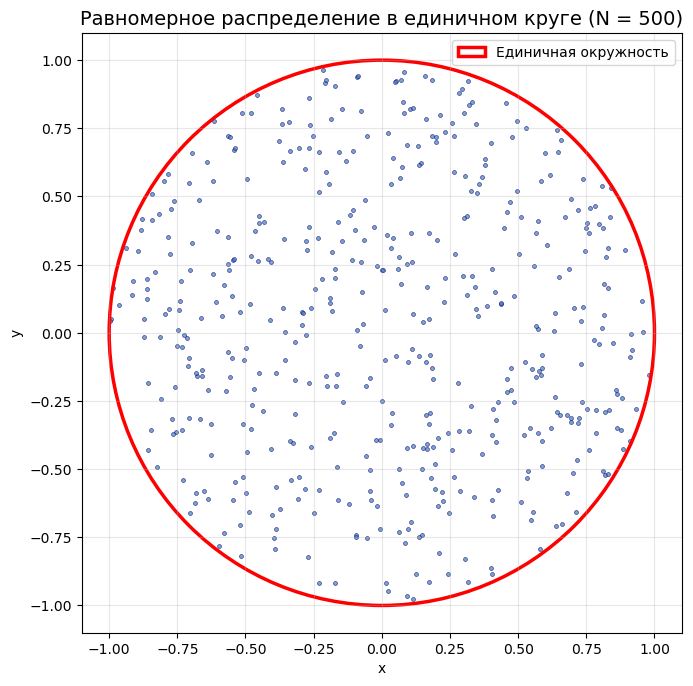

In [12]:
N = 500

def unit_circle_uniform_generator(N):
    #генерируем равномерно угол, а радиус по квадратичному закону,
    #т.к. площадь круга зависит квадратично от радиуса
    r = np.sqrt(np.random.rand(N))
    phi = np.random.rand(N) * 2 * PI
    return r * np.cos(phi), r * np.sin(phi)

x, y = unit_circle_uniform_generator(N)
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(x, y, s=8, alpha=0.7, color='steelblue', edgecolor='navy', linewidth=0.5)

circle = plt.Circle((0, 0), 1.0, 
                    color='red',      
                    fill=False,       
                    linewidth=2.5,    
                    linestyle='-',
                    label='Единичная окружность')
ax.add_patch(circle)
ax.set_aspect('equal')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
ax.set_title(f'Равномерное распределение в единичном круге (N = {N})', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

**Задача 9**

Докажите (устно), что приведенный ниже алгоритм (Box-Muller algorithm) формирует выборку из независимых N(0,1) случаных величин. Модифицируйте метод, чтобы исключить вызовы тригонометрических функций np.sin и np.cos. С помощью модифицированного метода смоделируйте выборку объема 1000 из двумерного гауссовского распределения со средним [4, 7] и ковариационной матрицей [[20, -4], [ -4, 40]]. Постройте 2D гистограмму полученного распределения. Сравните выборочное среднее и ковариационную матрицу с точными значениями.

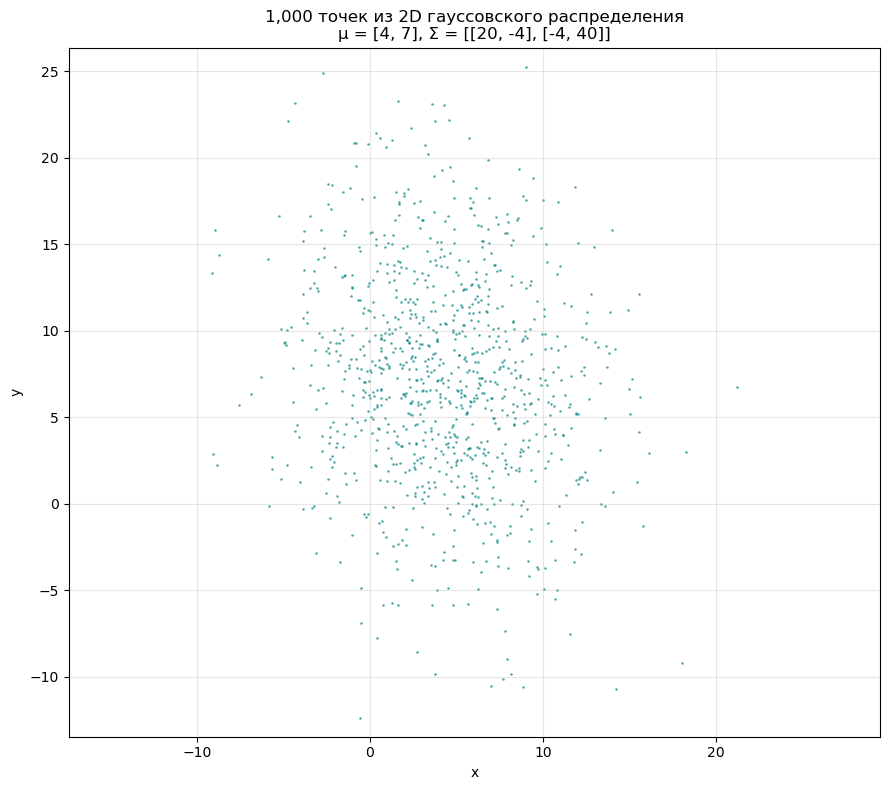

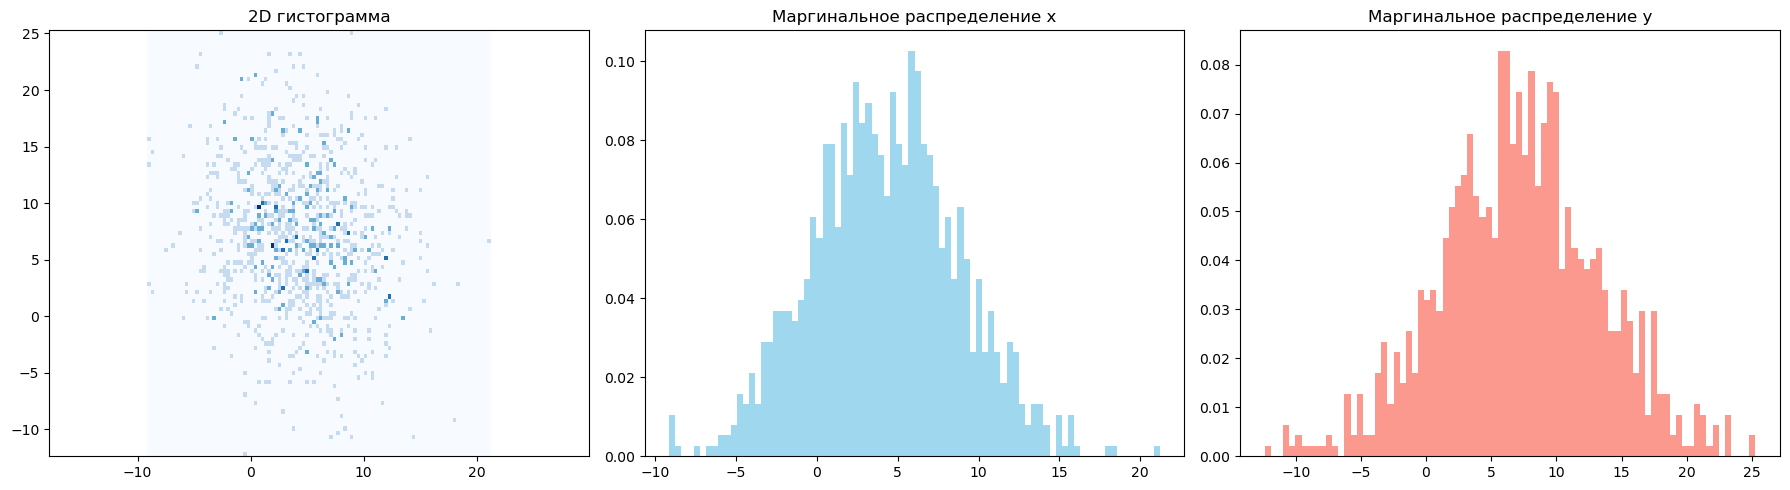

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import uniform

def standart_pairs(N):
    x = np.empty(N)
    y = np.empty(N)
    count = 0
    
    while count < N:
        u = uniform(-1, 1)
        v = uniform(-1, 1)
        s = u*u + v*v
        
        if s >= 1 or s == 0:
            continue
            
        multiplier = np.sqrt(-2 * np.log(s) / s)
        x[count] = u * multiplier
        y[count] = v * multiplier
        count += 1
    
    return x, y

def gaussian(mu, sigma, N):
    z1, z2 = standart_pairs(N)
    Z = np.vstack([z1, z2])
    
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(sigma, dtype=float)
    
    L = np.linalg.cholesky(Sigma)             
    X = mu[:, np.newaxis] + L @ Z
    return X.T

np.random.seed(42)
mu = [4, 7]
sigma = [[20, -4], [-4, 40]]
N = 1000

points = gaussian(mu, sigma, N)
x, y = points[:,0], points[:,1]

plt.figure(figsize=(9, 8))
plt.scatter(x, y, s=1, alpha=0.5, color='teal')
plt.title(f'{N:,} точек из 2D гауссовского распределения\n'
          f'μ = {mu}, Σ = [[20, -4], [-4, 40]]')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Три гистограммы
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

ax[0].hist2d(x, y, bins=100, cmap='Blues')
ax[0].set_title('2D гистограмма')
ax[0].axis('equal')

ax[1].hist(x, bins=80, alpha=0.8, color='skyblue', density=True)
ax[1].set_title('Маргинальное распределение x')

ax[2].hist(y, bins=80, alpha=0.8, color='salmon', density=True)
ax[2].set_title('Маргинальное распределение y')

plt.tight_layout()
plt.show()

### Задача 10*

Реализовать метод генерации случайного разбиения n-элементного множества на подмножества. С его помощью оценить ожидаемое число подмножеств в случайном разбиении множества из 100 элементов.

In [37]:
def bell(n): #через треугольник Эйткена
    triangle = [[0] * (i + 1) for i in range(n + 1)]
    triangle[0][0] = 1
    
    for i in range(1, n + 1):
        triangle[i][0] = triangle[i-1][-1]
        for j in range(1, i + 1):
            triangle[i][j] = triangle[i][j-1] + triangle[i-1][j-1]
    
    return triangle[n][n]  # B_n — правый нижний угол

def sample_dobinski_manual(n, size=1):
    if n == 0:
        return np.zeros(size, dtype=int)
    
    B_n = bell(n)
    M = np.e * B_n
    
    max_k_proposal = min(n + 30, 60)
    log_weights = np.zeros(max_k_proposal + 1)
    log_fact = 0.0
    for k in range(1, max_k_proposal + 1):
        log_fact += np.log(k)
        log_weights[k] = n * np.log(k) - log_fact
    
    max_log_weight = np.max(log_weights)
    
    samples = []
    while len(samples) < size:
        k = sample_discrete(
            values=list(range(1, max_k_proposal + 1)),
            weights=[1.0] * max_k_proposal,
            size=1
        )[0]
        log_target = log_weights[k]
        log_envelope = max_log_weight
        
        if np.log(np.random.random()) < log_target - log_envelope:
            if np.log(np.random.random()) < log_target - np.log(M):
                samples.append(k)
    
    return np.array(samples)
    
def random_partition(A, N=1):
    n = len(A)
    result = []
    ks = sample_dobinski(n, N)
    partitions = []
    
    for k in ks:
        colors = sample_discrete(list(range(k)), [1 for _ in range(k)], n)
        
        partition = {}
        for i in range(n):
            if colors[i] in partition:
                partition[colors[i]].append(i)
            else:
                partition[colors[i]] = [i]
        
        blocks = list(partition.values())
        partitions.append(blocks)
    return partitions

n = 100
N_samples = 100

partitions = random_partition(range(n), N_samples)
num_blocks = [len(part) for part in partitions]

print(f"Оценка среднего число блоков: {np.mean(num_blocks)}")

Оценка среднего число блоков: 28.24
